## Logistic regression

In [1]:
import numpy as np
import math

In [2]:
class LogisticRegression:
    def __init__(self, learning_rate=0.001, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def loss(self, h, y):
        return (-y * np.log(h) - (1 - y) * np.log(1 - h)).mean()

    def fit(self, X, y):
        
        n_samples = len(X)
        
        # create matrix multiplication features
        X = self._create_matrix_features(X)

        # initialize beta 
        self.beta = np.repeat(0, X.shape[1])

        self.cost = []

        for _ in range(self.num_iterations):
            # calculate the predicted values for Y using the current coefficients
            z = X.dot(self.beta)
            predictions = self._sigmoid(z)

            # compute the cost function
            self.cost.append(self.loss(predictions,y))

            # calculate the error between the predicted and actual values of Y
            error = predictions - y

            print('error = ',error)

            print(X.T.dot(error))

            # calculate the gradients of β
            gradient = X.T.dot(error) / n_samples

            print('gradient = ', gradient)

            # update the coefficients using the gradient and the learning rate
            self.beta = self.beta - self.learning_rate * gradient
            print('beta = ', self.beta)

    def _create_matrix_features(self, X):
        # Add a column of 1s to the independent variables matrix to represent the intercept term
        X = np.column_stack((np.ones(len(X)), X))   
        return X

    def predict_probability(self, X):
        return self._sigmoid(self._create_matrix_features(X).dot(self.beta))

    def predict(self, X, threshold=0.5):
        return self.predict_probability(X) >= threshold

## Example

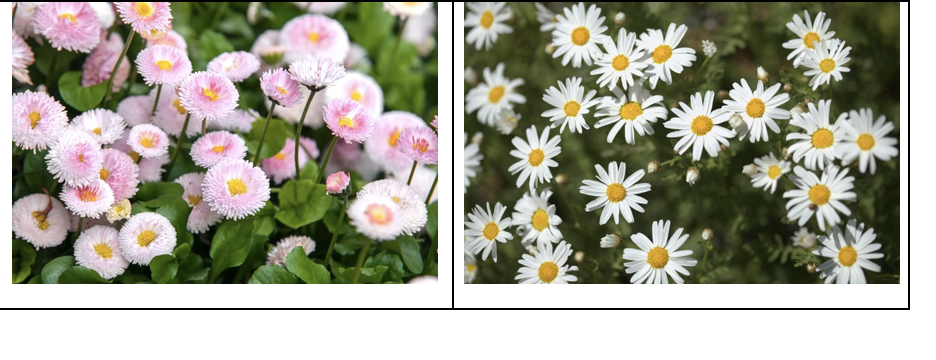

Suppose we are trying to classify daisies into two types: English (left image) and Marguerite (right image). We have a dataset record data set with information about petal length (in cm) and petal width (in cm) as well as the corresponding class: 0 for English and 1 for Marguerite. 

length = {1.1, 0.9, 1.1, 0.9, 1.4, 1.5, 1.6} 

width =  {0.1, 0.2, 0.2, 0.1, 0.6, 0.7, 0.8} 

class = {0, 0, 0, 0, 1, 1, 1} 

The logistic regression equation could be written as:

$age=\beta_0 + \beta_1  length + \beta_2  width + e$

First, we pick $b_0,b_1,b_2=0$ and $α=0.001$.

In [3]:
# collect data
X1 = np.array([1.1, 0.9, 1.1, 0.9, 1.4, 1.5, 1.6])
X2 = np.array([0.1, 0.2, 0.2, 0.1, 0.6, 0.7, 0.8])
X = np.column_stack((X1,X2))
y = np.array([0, 0, 0, 0, 1, 1, 1])

In [6]:
length = np.array([2.1, 1.9, 2.2, 1.8, 3.0, 3.2, 3.1]) 

width = np.array([0.5, 0.6, 0.5, 0.4, 1.5, 1.6, 1.7])
X = np.column_stack((length,width))
y  = np.array([0, 0, 0, 0, 1, 1, 1])

# create an instance of the LogisticRegression class
model = LogisticRegression(learning_rate=0.1, num_iterations=20)
model.fit(X,y)

error =  [ 0.5  0.5  0.5  0.5 -0.5 -0.5 -0.5]
[ 0.5  -0.65 -1.4 ]
gradient =  [ 0.07142857 -0.09285714 -0.2       ]
beta =  [-0.00714286  0.00928571  0.02      ]
error =  [ 0.50558905  0.50562476  0.50582117  0.50439274 -0.48732415 -0.48636053
 -0.48609287]
[ 0.56165018 -0.48207647 -1.32468388]
gradient =  [ 0.08023574 -0.06886807 -0.18924055]
beta =  [-0.01516643  0.01617252  0.03892406]
error =  [ 0.50956331  0.50972772  0.50996747  0.5073779  -0.47708177 -0.47530408
 -0.47473671]
[ 0.60951383 -0.35012792 -1.26460841]
gradient =  [ 0.0870734  -0.05001827 -0.18065834]
beta =  [-0.02387377  0.02117435  0.05698989]
error =  [ 0.51226936  0.51263517  0.51279839  0.50925794 -0.46875723 -0.46628425
 -0.46539304]
[ 0.64652634 -0.24650649 -1.21654066]
gradient =  [ 0.09236091 -0.03521521 -0.17379152]
beta =  [-0.03310986  0.02469587  0.07436904]
error =  [ 0.51398035  0.51460427  0.51459724  0.51027113 -0.46194093 -0.45886633
 -0.45763316]
[ 0.67501258 -0.165149   -1.17791408]
gradient =  [ 

In [7]:
model.predict_probability(np.array([2.5,1.0]).reshape(1,2))

array([0.5373972])

In [8]:
# create an instance of the LogisticRegression class
model = LogisticRegression(learning_rate=0.001, num_iterations=1)

# fit the model to the training data
model.fit(X, y)

print('beta = ',model.beta)

X_new = np.array([[1.5, 0.6]])

# make predictions on the test set
y_pred = model.predict(X_new)

print('prediction = ',y_pred)

# calculate the accuracy of the predictions
#accuracy = np.mean(y_pred == y_test)
#print("Accuracy: ", accuracy)

error =  [ 0.5  0.5  0.5  0.5 -0.5 -0.5 -0.5]
[ 0.5  -0.65 -1.4 ]
gradient =  [ 0.07142857 -0.09285714 -0.2       ]
beta =  [-7.14285714e-05  9.28571429e-05  2.00000000e-04]
beta =  [-7.14285714e-05  9.28571429e-05  2.00000000e-04]
prediction =  [ True]
